# Pattern Recognition 3 - Points and Neighbourhoods

**Objectives**:

* Detect points of interest in an image
* Extract neighbourhood descriptors
* Use descriptors for clustering and matching

## Points of interest

In the previous labs, we have analyzed the images either using "object descriptors" (area, eccentricity, moments of segmented object) or "image descriptors" (based on all the pixels of the image). Another way of approaching an image analysis problem is to first look for "interesting points".

What makes a point *interesting* will highly depend on the application. Common examples are **corners**, or **local extrema**.

Starting from the `mitosis.bmp` image, find or create a **point detector** that will detect the nuclei of the cells.

> *Hint: it may be easier to do so in a different color space...*

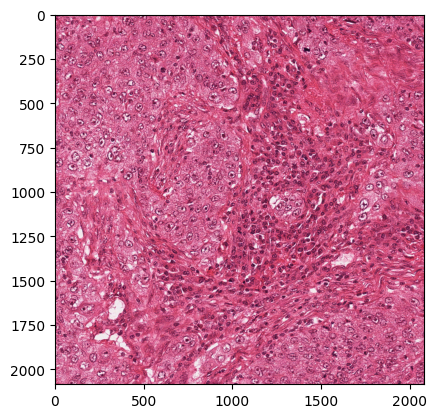

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from skimage.io import imread
%matplotlib inline

im = imread('mitosis.bmp')
plt.figure()
plt.imshow(im)
plt.show()

/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/skimage/color/colorconv.py:1736: RuntimeWarning: divide by zero encountered in matmul
  stains = (np.log(rgb) / log_adjust) @ conv_matrix
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/skimage/color/colorconv.py:1736: RuntimeWarning: overflow encountered in matmul
  stains = (np.log(rgb) / log_adjust) @ conv_matrix
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/skimage/color/colorconv.py:1736: RuntimeWarning: invalid value encountered in matmul
  stains = (np.log(rgb) / log_adjust) @ conv_matrix


detected points: 2150


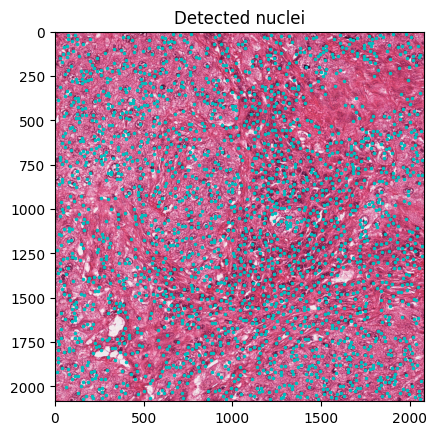

In [2]:
# The image is an H&E stained tissue: nuclei are stained by haematoxylin
# (purple/blue) while the rest of the tissue is pink (eosin). It is therefore
# easier to work in the "stain" colour space: rgb2hed separates the stains and
# the first channel (Haematoxylin) makes the nuclei stand out clearly.
from skimage.color import rgb2hed
from skimage.filters import gaussian
from skimage.feature import peak_local_max

def detect_points(im, min_distance=12, percentile=85, sigma=3):
    H = rgb2hed(im)[:, :, 0]              # haematoxylin channel -> nuclei
    H = gaussian(H, sigma=sigma)         # smooth so each nucleus becomes one blob
    coords = peak_local_max(H, min_distance=min_distance,
                            threshold_abs=np.percentile(H, percentile))
    return coords

coords = detect_points(im)
print("detected points:", len(coords))

plt.figure()
plt.imshow(im)
plt.plot(coords[:, 1], coords[:, 0], 'c.', markersize=3)
plt.title("Detected nuclei")
plt.show()

## Descriptors

The goal of *descriptors* is to represent the region surrounding the point of interest in a way that allow our algorithm to best perform its task. For instance, the BRIEF descriptor will compare pairs of pixels in the given neighbourhood and create a binary descriptor representing the result of all these comparison. This kind of descriptor will tend to create a unique signature in a grayscale image, and is very useful for applications such as matching for stereo-vision or for video tracking.

Other types of descriptors can be based on the texture (for instance with local Fourier transforms) or on local histograms.

* Using the points detected before, **extract neighbourhood patches** and **compute the concatenated color histogram** as a descriptor (meaning a 256+256+256 = size 768 vector, with the first 256 values corresponding to the R histogram, etc...).
* Use the [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) class from `scikit-learn` to cluster the points of interest depending on their descriptor. Can you identify clusters representing the type of tissue of the cell?

descriptor matrix: (2150, 768)


/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encoun

cluster sizes: [382 538 559 671]


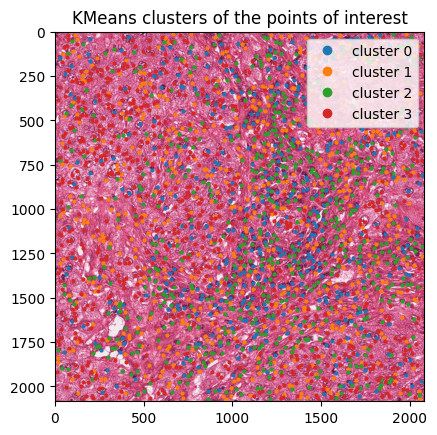

In [3]:
from sklearn.cluster import KMeans

def compute_histogram(patch):
    rgb_histogram = np.zeros((768,))
    # one 256-bin histogram per colour channel, concatenated (R | G | B)
    for c in range(3):
        hist, _ = np.histogram(patch[:, :, c], bins=256, range=(0, 256))
        rgb_histogram[c * 256:(c + 1) * 256] = hist
    return rgb_histogram

def extract_descriptors(im, coords, neighbourhood_size=15):
    r = neighbourhood_size // 2
    descriptors = []
    for y, x in coords:
        # extract the square neighbourhood patch centered on the point
        patch = im[y - r:y + r + 1, x - r:x + r + 1]
        descriptors.append(compute_histogram(patch))
    return np.array(descriptors)

# Keep only the points whose full patch fits inside the image
r = 15 // 2
valid = ((coords[:, 0] >= r) & (coords[:, 1] >= r) &
         (coords[:, 0] < im.shape[0] - r) & (coords[:, 1] < im.shape[1] - r))
coords = coords[valid]

descriptors = extract_descriptors(im, coords)
print("descriptor matrix:", descriptors.shape)

# Cluster the points according to their colour-histogram descriptor
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10).fit(descriptors)
labels = kmeans.labels_
print("cluster sizes:", np.bincount(labels))

# The clusters group points sharing a similar local colour: they correspond to
# different tissue contexts (dense nuclei zones, lighter stroma, ...).
plt.figure()
plt.imshow(im)
for k in range(kmeans.n_clusters):
    m = labels == k
    plt.plot(coords[m, 1], coords[m, 0], '.', markersize=4, label="cluster %d" % k)
plt.legend(markerscale=3)
plt.title("KMeans clusters of the points of interest")
plt.show()

* Apply the same point detection and descriptors on the `mitosis2.bmp` image, and use the already trained KMeans to predict the clusters of the points in the new image.

/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/skimage/color/colorconv.py:1736: RuntimeWarning: divide by zero encountered in matmul
  stains = (np.log(rgb) / log_adjust) @ conv_matrix
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/skimage/color/colorconv.py:1736: RuntimeWarning: overflow encountered in matmul
  stains = (np.log(rgb) / log_adjust) @ conv_matrix
/Users/andreasamrani/Documents/MA2_Q2/Pattern Image Recognition /LABO/.venv/lib/python3.9/site-packages/skimage/color/colorconv.py:1736: RuntimeWarning: invalid value encountered in matmul
  stains = (np.log(rgb) / log_adjust) @ conv_matrix


detected points: 2176 | cluster sizes: [224 610 357 985]


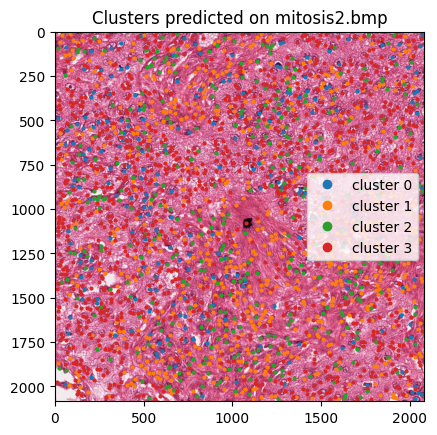

In [4]:
# Same detection + descriptors on the second image, then PREDICT the clusters
# with the KMeans already trained on the first image (no new fit).
im2 = imread('mitosis2.bmp')

coords2 = detect_points(im2)
valid2 = ((coords2[:, 0] >= r) & (coords2[:, 1] >= r) &
          (coords2[:, 0] < im2.shape[0] - r) & (coords2[:, 1] < im2.shape[1] - r))
coords2 = coords2[valid2]

descriptors2 = extract_descriptors(im2, coords2)
labels2 = kmeans.predict(descriptors2)
print("detected points:", len(coords2), "| cluster sizes:", np.bincount(labels2))

plt.figure()
plt.imshow(im2)
for k in range(kmeans.n_clusters):
    m = labels2 == k
    plt.plot(coords2[m, 1], coords2[m, 0], '.', markersize=4, label="cluster %d" % k)
plt.legend(markerscale=3)
plt.title("Clusters predicted on mitosis2.bmp")
plt.show()